In [2]:
print("과제 2")

과제 2


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix, accuracy_score
from scipy.stats import mode

print("분석을 위해 필요한 라이브러리")
print("pandas, numpy, matplotlib, seaborn, sklearn, scipy")
print("pandas: 데이터 조작 및 분석을 위한 라이브러리")
print("numpy: 수치 계산을 위한 라이브러리")
print("matplotlib: 데이터 시각화를 위한 라이브러리")
print("seaborn: 통계적 데이터 시각화를 위한 라이브러리")
print("sklearn: 머신 러닝을 위한 라이브러리")
print("scipy: 과학적 계산을 위한 라이브러리")

분석을 위해 필요한 라이브러리
pandas, numpy, matplotlib, seaborn, sklearn, scipy
pandas: 데이터 조작 및 분석을 위한 라이브러리
numpy: 수치 계산을 위한 라이브러리
matplotlib: 데이터 시각화를 위한 라이브러리
seaborn: 통계적 데이터 시각화를 위한 라이브러리
sklearn: 머신 러닝을 위한 라이브러리
scipy: 과학적 계산을 위한 라이브러리


In [5]:
data = load_iris(as_frame=True)

df = data.frame.copy()
df["species"] = df["target"].map(dict(enumerate(data.target_names)))

X = data.data
y = data.target

print("데이터 크기:", X.shape)
print("클래스 이름:", data.target_names)
print("클래스 분포:")
print(df["species"].value_counts())
# dataset 불러와 데이터프레임으로 변환, 클래스 이름과 클래스 분포 확인

데이터 크기: (150, 4)
클래스 이름: ['setosa' 'versicolor' 'virginica']
클래스 분포:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [6]:
print(df[data.feature_names].describe())

print(df.groupby("species")[data.feature_names].mean().round(2))

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
species                                                              
setosa                   5.01           

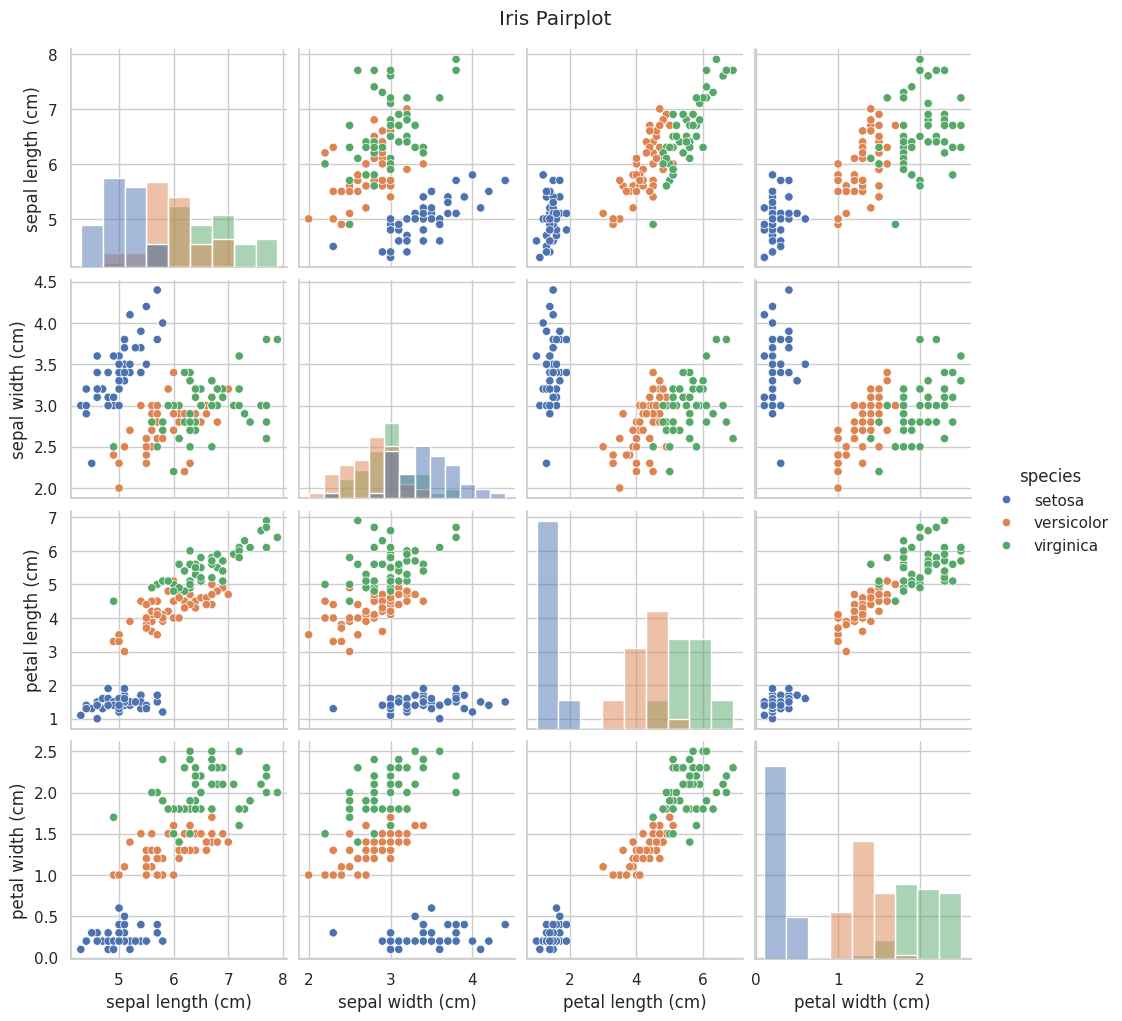

In [7]:
sns.set_theme(style="whitegrid")

pair = sns.pairplot(
    df,
    vars=data.feature_names,
    hue="species",
    diag_kind="hist"
)

pair.fig.suptitle("Iris Pairplot", y=1.02)
plt.show()

In [8]:
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

print("표준화된 데이터 일부:")
print(X_std[:5])

표준화된 데이터 일부:
[[-0.90068117  1.01900435 -1.34022653 -1.3154443 ]
 [-1.14301691 -0.13197948 -1.34022653 -1.3154443 ]
 [-1.38535265  0.32841405 -1.39706395 -1.3154443 ]
 [-1.50652052  0.09821729 -1.2833891  -1.3154443 ]
 [-1.02184904  1.24920112 -1.34022653 -1.3154443 ]]


In [9]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_std)

cluster_labels = kmeans.labels_

print("군집 결과 레이블:")
print(cluster_labels)

print("군집별 데이터 개수:")
print(pd.Series(cluster_labels).value_counts().sort_index())

군집 결과 레이블:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
군집별 데이터 개수:
0    53
1    50
2    47
Name: count, dtype: int64


In [10]:
comparison = pd.crosstab(
    pd.Series(y, name="Actual"),
    pd.Series(cluster_labels, name="Cluster")
)

print(comparison)

Cluster   0   1   2
Actual             
0         0  50   0
1        39   0  11
2        14   0  36


In [11]:
mapped_labels = np.zeros_like(cluster_labels)

for cluster in np.unique(cluster_labels):
    mask = cluster_labels == cluster
    mapped_labels[mask] = mode(y[mask], keepdims=True).mode[0]

print("변환 전 군집 레이블:")
print(cluster_labels)

print("변환 후 군집 레이블:")
print(mapped_labels)

변환 전 군집 레이블:
[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]
변환 후 군집 레이블:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 2 2 2 1 1 1 2 1 1 1 1 1 1 1 1 2 1 1 1 1 2 1 1 1
 1 2 2 2 1 1 1 1 1 1 1 2 2 1 1 1 1 1 1 1 1 1 1 1 1 1 2 1 2 2 2 2 1 2 2 2 2
 2 2 1 1 2 2 2 2 1 2 1 2 1 2 2 1 2 2 2 2 2 2 1 1 2 2 2 1 2 2 2 1 2 2 2 1 2
 2 1]


K-Means 군집화 정확도: 0.8333
혼동행렬:
[[50  0  0]
 [ 0 39 11]
 [ 0 14 36]]


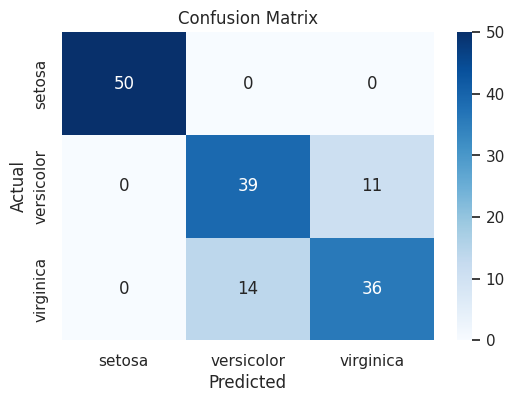

In [14]:
acc = accuracy_score(y, mapped_labels)
cm = confusion_matrix(y, mapped_labels)

print("K-Means 군집화 정확도:", round(acc, 4))
print("혼동행렬:")
print(cm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

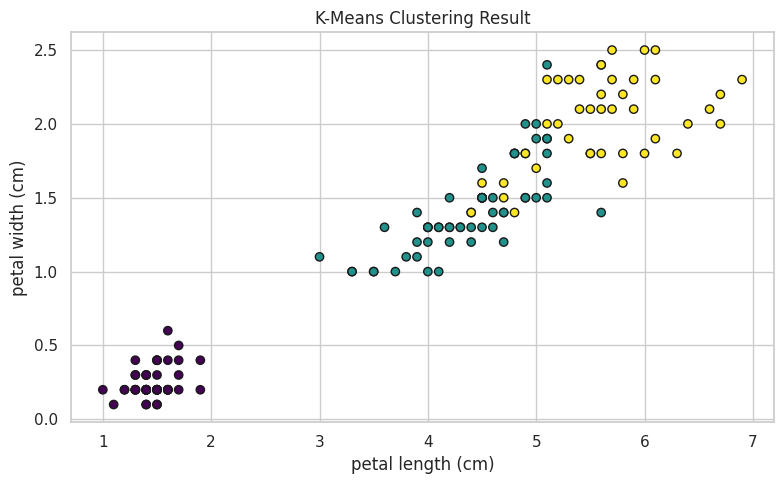

In [13]:
plt.figure(figsize=(8, 5))

plt.scatter(
    X["petal length (cm)"],
    X["petal width (cm)"],
    c=mapped_labels,
    cmap="viridis",
    edgecolor="k"
)

plt.xlabel("petal length (cm)")
plt.ylabel("petal width (cm)")
plt.title("K-Means Clustering Result")
plt.tight_layout()
plt.show()